In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set the style for the plots
plt.style.use('ggplot')
sns.set_palette("colorblind")

# Load the data
df = pd.read_csv('scheduling_data.csv')

# Clean the data
df = df.fillna({'Status': 'Not Scheduled'})

<Figure size 1200x600 with 0 Axes>

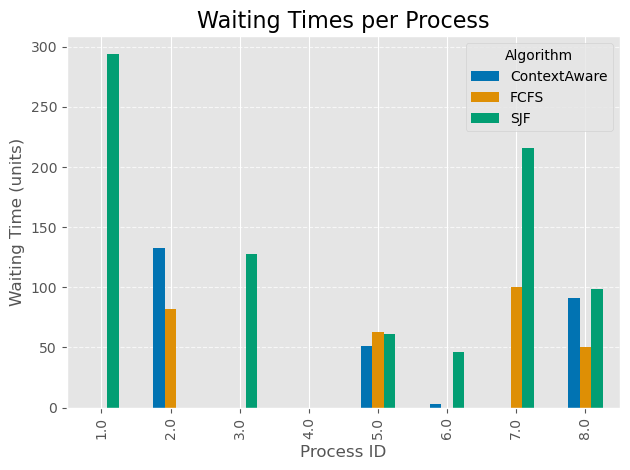

In [2]:
# 1. Bar Chart for Waiting Times per Process
plt.figure(figsize=(12, 6))
process_data = df[(df['Type'] == 'Process') & (df['Status'] == 'Scheduled')].copy()

# Create a pivot table to organize data by scheduling algorithm and process ID
waiting_times = process_data.pivot(index='Process ID', columns='Scheduling Algorithm', values='Waiting Time')

# Plot the waiting times
waiting_times.plot(kind='bar')
plt.title('Waiting Times per Process', fontsize=16)
plt.xlabel('Process ID', fontsize=12)
plt.ylabel('Waiting Time (units)', fontsize=12)
plt.legend(title='Algorithm')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
# 2. Bar Chart for Aggregate Metrics Comparison
plt.figure(figsize=(12, 6))

# Extract summary metrics
metrics_of_interest = ['Total Execution Time', 'Avg Waiting Time', 'Throughput', 'CPU Utilization', 'Fairness\n(Variance of\nWaiting Times)']
summary_data = df[df['Type'] == 'Summary'].copy()

# Create a dictionary to store the data for the metrics
metrics_data = {}
for metric in metrics_of_interest:
    # Use the original metric name for filtering
    filter_metric = metric.replace('\n', ' ')
    # Print to debug what's happening
    print(f"Looking for metric: '{filter_metric}'")
    matching_data = summary_data[summary_data['Metric'] == filter_metric]
    if matching_data.empty:
        print(f"No data found for metric: '{filter_metric}'")
        print("Available metrics:", summary_data['Metric'].unique())
    else:
        metrics_data[metric] = matching_data.pivot(index='Metric', columns='Scheduling Algorithm', values='Value')

# Only use metrics that were found in the data
valid_metrics = list(metrics_data.keys())
print(f"Valid metrics found: {valid_metrics}")

# Combine the data into a single DataFrame
if metrics_data:
    metrics_df = pd.concat(metrics_data.values())
    metrics_df.index = valid_metrics

    # Normalize the data for better visualization (since metrics have vastly different scales)
    normalized_metrics = metrics_df.div(metrics_df.max(axis=1), axis=0)

    # Plot the normalized metrics
    ax = normalized_metrics.plot(kind='bar')
    plt.title('Normalized Aggregate Metrics Comparison', fontsize=16)
    plt.xlabel('Metric', fontsize=12)
    plt.ylabel('Normalized Value', fontsize=12)
    plt.legend(title='Algorithm')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    # Adjust the spacing to accommodate the multi-line labels
    plt.tight_layout()
    plt.show()
else:
    print("No valid metrics found to plot")

Looking for metric: 'Total Execution Time'
Looking for metric: 'Avg Waiting Time'
No data found for metric: 'Avg Waiting Time'
Available metrics: ['Total Execution Time' 'Average Waiting Time' 'Throughput'
 'Process Scoring' 'Node Scoring' 'Resource Checks' 'Retry Attempts'
 'Partitioning Attempts' 'Scheduling Overhead (Total Calculations)'
 '===== [2025-05-26 13' 'Assignment Attempts']
Looking for metric: 'Throughput'
Looking for metric: 'CPU Utilization'
No data found for metric: 'CPU Utilization'
Available metrics: ['Total Execution Time' 'Average Waiting Time' 'Throughput'
 'Process Scoring' 'Node Scoring' 'Resource Checks' 'Retry Attempts'
 'Partitioning Attempts' 'Scheduling Overhead (Total Calculations)'
 '===== [2025-05-26 13' 'Assignment Attempts']
Looking for metric: 'Fairness (Variance of Waiting Times)'
No data found for metric: 'Fairness (Variance of Waiting Times)'
Available metrics: ['Total Execution Time' 'Average Waiting Time' 'Throughput'
 'Process Scoring' 'Node Scor

TypeError: unsupported operand type(s) for /: 'str' and 'str'

<Figure size 1200x600 with 0 Axes>

In [3]:
# 3. Pie Chart for Calculation Counts (Scheduling Overhead)
plt.figure(figsize=(10, 8))

# Extract ContextAware calculation counts
context_aware_calcs = df[(df['Scheduling Algorithm'] == 'ContextAware') & 
                          (df['Type'] == 'Summary') &
                          (df['Metric'].isin(['Process Scoring', 'Node Scoring', 
                                              'Resource Checks', 'Retry Attempts', 
                                              'Partitioning Attempts']))].copy()

# Prepare data for pie chart
calc_types = context_aware_calcs['Metric'].tolist()
calc_values = context_aware_calcs['Value'].tolist()

# Calculate percentages
total_calcs = sum(calc_values)
calc_percentages = [f"{calc}: {val} ({val/total_calcs*100:.1f}%)" for calc, val in zip(calc_types, calc_values)]

# Plot the pie chart
wedges, texts, autotexts = plt.pie(calc_values, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.5))
plt.title('ContextAware Scheduler Calculation Distribution', fontsize=16)

# Add legend
plt.legend(wedges, calc_percentages, title="Calculation Types", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for +: 'int' and 'str'

<Figure size 1000x800 with 0 Axes>

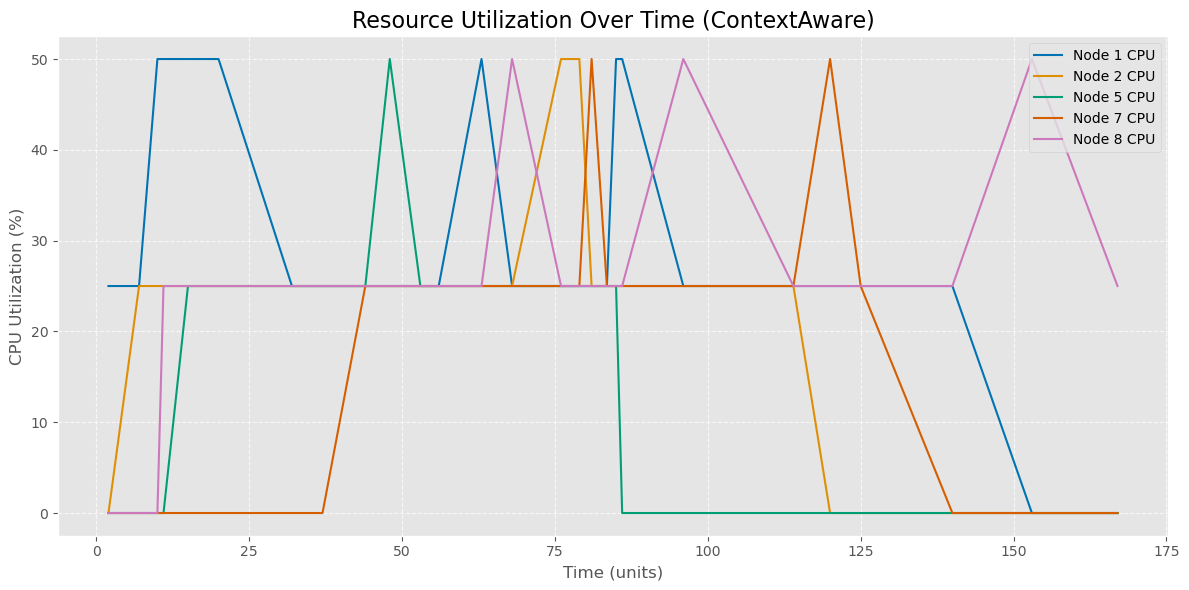

In [ ]:
# 4. Line Plot for Resource Utilization Over Time
plt.figure(figsize=(12, 6))

# Filter ContextAware processes
context_aware_processes = df[(df['Scheduling Algorithm'] == 'ContextAware') & 
                             (df['Type'] == 'Process') & 
                             (df['Status'] == 'Scheduled')].copy()

# Extract the time points (start and completion times)
time_points = pd.concat([
    context_aware_processes['Start Time'].rename('time'),
    context_aware_processes['Completion Time'].rename('time')
]).sort_values().unique()

# Create a time-series with unique timestamps
time_series = pd.DataFrame(index=time_points)

# Define some nodes to visualize (based on assigned nodes in data)
nodes = [1, 2, 5, 7, 8]  # Selected based on frequency in the data

# Simulate CPU utilization based on assigned nodes and process timelines
for node in nodes:
    # Initialize CPU utilization series for this node
    cpu_util = []
    
    for t in time_points:
        # Count active processes on this node at time t
        active_processes = context_aware_processes[
            ((context_aware_processes['Start Time'] <= t) & 
             (context_aware_processes['Completion Time'] >= t) &
             (context_aware_processes['Assigned Nodes'].astype(str).str.contains(str(node))))
        ].shape[0]
        
        # Assume each node has capacity of 4 processes
        # Normalize to percentage (0-100%)
        utilization = min(active_processes / 4 * 100, 100)
        cpu_util.append(utilization)
    
    # Add to time series
    time_series[f'Node {node} CPU'] = cpu_util

# Plot resource utilization over time
for node in nodes:
    plt.plot(time_points, time_series[f'Node {node} CPU'], label=f'Node {node} CPU')

plt.title('Resource Utilization Over Time (ContextAware)', fontsize=16)
plt.xlabel('Time (units)', fontsize=12)
plt.ylabel('CPU Utilization (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

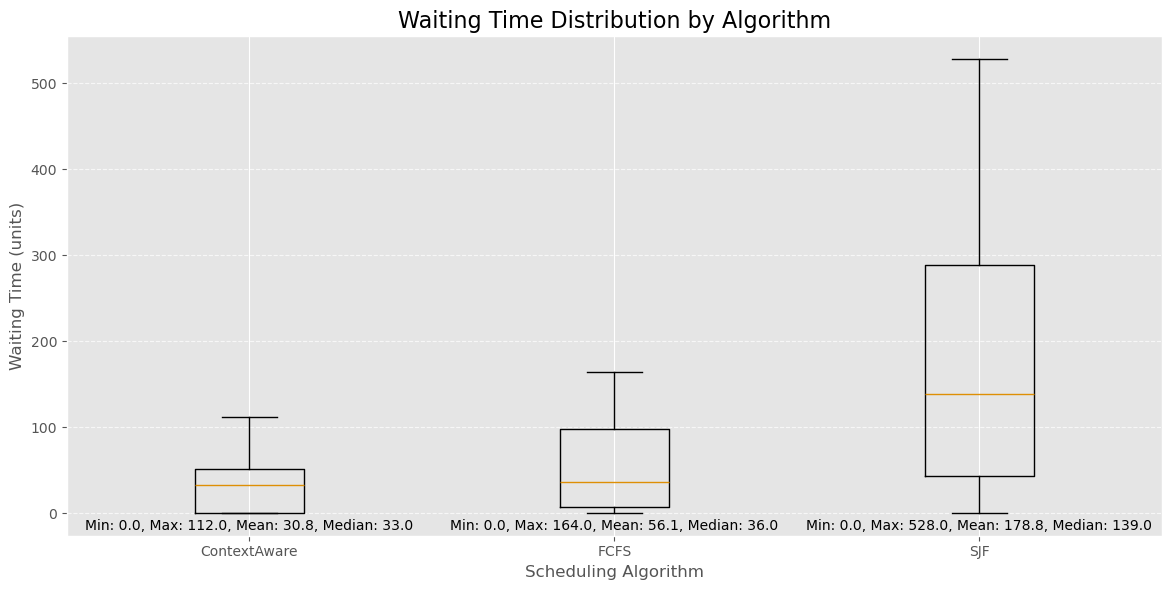

In [ ]:
# 5. Box Plot for Waiting Time Distribution
plt.figure(figsize=(12, 6))

# Prepare data for box plot - waiting times by algorithm
algorithms = df['Scheduling Algorithm'].unique()
waiting_time_data = []

for algo in algorithms:
    algo_waiting_times = df[(df['Scheduling Algorithm'] == algo) & 
                           (df['Type'] == 'Process') & 
                           (df['Status'] == 'Scheduled')]['Waiting Time'].tolist()
    waiting_time_data.append(algo_waiting_times)

# Plot the box plot
plt.boxplot(waiting_time_data, labels=algorithms)
plt.title('Waiting Time Distribution by Algorithm', fontsize=16)
plt.xlabel('Scheduling Algorithm', fontsize=12)
plt.ylabel('Waiting Time (units)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add summary statistics as text for each algorithm
y_pos = df[(df['Type'] == 'Process') & (df['Status'] == 'Scheduled')]['Waiting Time'].min() - 20
for i, algo in enumerate(algorithms):
    algo_waiting_times = df[(df['Scheduling Algorithm'] == algo) & 
                           (df['Type'] == 'Process') & 
                           (df['Status'] == 'Scheduled')]['Waiting Time']
    
    stats_text = (f"Min: {algo_waiting_times.min():.1f}, "
                  f"Max: {algo_waiting_times.max():.1f}, "
                  f"Mean: {algo_waiting_times.mean():.1f}, "
                  f"Median: {algo_waiting_times.median():.1f}")
    
    plt.annotate(stats_text, xy=(i+1, y_pos), ha='center', fontsize=10)

plt.tight_layout()
plt.show()